# Reducción de Dimensionalidad: Comprar vs Alquilar Vivienda
## Marco Antonio Ortega Reséndiz

**Objetivo:** Reducir las 9 variables predictoras a un número menor de componentes que conserven la mayor parte de la información, y visualizar los datos en 2D.

Justificación del algoritmo

Se eligió **PCA (Análisis de Componentes Principales)** porque:
- Es el método estándar y más interpretable para reducción de dimensionalidad lineal.
- Permite visualizar en 2D un conjunto de 9 variables, facilitando detectar patrones/separación entre quienes compran y quienes alquilan.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


#### Carga y exploración de datos

In [3]:
df = pd.read_csv('C:/Users/style/Downloads/SA_datos/comprar_alquilar.csv')
print(df.shape)
df.head()


(202, 10)


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [4]:
df.describe().round(1)


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.0,202.0,202.0,202.0,202.0,202.0,202.0,202.0,202.0,202.0
mean,4959.0,971.6,211.7,515.4,38749.7,373349.6,1.0,1.2,4.5,0.3
std,1682.9,272.1,124.9,168.1,17365.2,136371.5,0.8,1.4,2.5,0.5
min,2008.0,384.0,0.0,201.0,10319.0,176553.0,0.0,0.0,0.0,0.0
25%,3513.8,766.8,99.0,383.2,24964.2,274810.0,0.0,0.0,2.0,0.0
50%,4947.5,968.0,208.5,522.5,38523.0,340783.5,1.0,1.0,5.0,0.0
75%,6374.5,1165.2,318.8,656.8,52150.8,444482.0,2.0,2.0,7.0,1.0
max,7984.0,1585.0,448.0,828.0,69934.0,669540.0,2.0,4.0,8.0,1.0


In [5]:
print(df['comprar'].value_counts())
print('Escalas muy distintas entre variables, por ejemplo:')
print(df[['hijos','ingresos','vivienda']].describe().loc[['min','max']])


comprar
0    135
1     67
Name: count, dtype: int64
Escalas muy distintas entre variables, por ejemplo:
     hijos  ingresos  vivienda
min    0.0    2008.0  176553.0
max    4.0    7984.0  669540.0


#### Gráfica de dispersión: comportamiento de los datos (variables originales)

Antes de reducir dimensiones, vemos dos variables clave en su escala original.

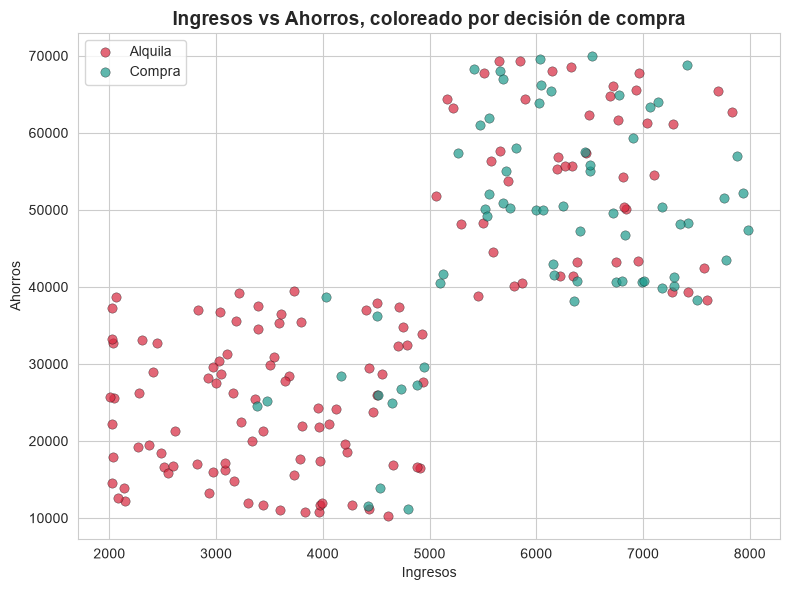

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
colors = {1: '#1B998B', 0: '#D7263D'}
for val, grp in df.groupby('comprar'):
    ax.scatter(grp['ingresos'], grp['ahorros'], s=45, alpha=0.7,
               label='Compra' if val==1 else 'Alquila', color=colors[val], edgecolor='black', linewidth=0.3)
ax.set_xlabel('Ingresos')
ax.set_ylabel('Ahorros')
ax.set_title('Ingresos vs Ahorros, coloreado por decisión de compra', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_original.png', dpi=120)
plt.show()


**Interpretación:** Con solo 2 de las 9 variables ya se nota cierta tendencia (mayores ingresos/ahorros asociados a comprar), pero para aprovechar toda la información disponible necesitamos reducir las 9 variables a componentes principales.

#### Diseño del modelo: separación de variables

In [10]:
X = df.drop(columns=['comprar'])
y = df['comprar']
print('Variables usadas para PCA:', list(X.columns))


Variables usadas para PCA: ['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros', 'vivienda', 'estado_civil', 'hijos', 'trabajo']


#### PCA sin escalar los datos

In [11]:
pca_sin_escalar = PCA()
componentes_sin_escalar = pca_sin_escalar.fit_transform(X)

print('Varianza explicada por componente (sin escalar):')
print(np.round(pca_sin_escalar.explained_variance_ratio_[:5], 4))
print('Varianza acumulada primeros 2 componentes:', round(pca_sin_escalar.explained_variance_ratio_[:2].sum(), 4))


Varianza explicada por componente (sin escalar):
[9.899e-01 1.010e-02 1.000e-04 0.000e+00 0.000e+00]
Varianza acumulada primeros 2 componentes: 0.9999


#### PCA escalando los datos (StandardScaler)

In [12]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

pca_escalado = PCA()
componentes_escalado = pca_escalado.fit_transform(X_escalado)

print('Varianza explicada por componente (escalado):')
print(np.round(pca_escalado.explained_variance_ratio_[:5], 4))
print('Varianza acumulada primeros 2 componentes:', round(pca_escalado.explained_variance_ratio_[:2].sum(), 4))


Varianza explicada por componente (escalado):
[0.2991 0.2329 0.1171 0.1069 0.0964]
Varianza acumulada primeros 2 componentes: 0.5321


#### Gráfica comparativa: los dos primeros componentes, con y sin escalamiento

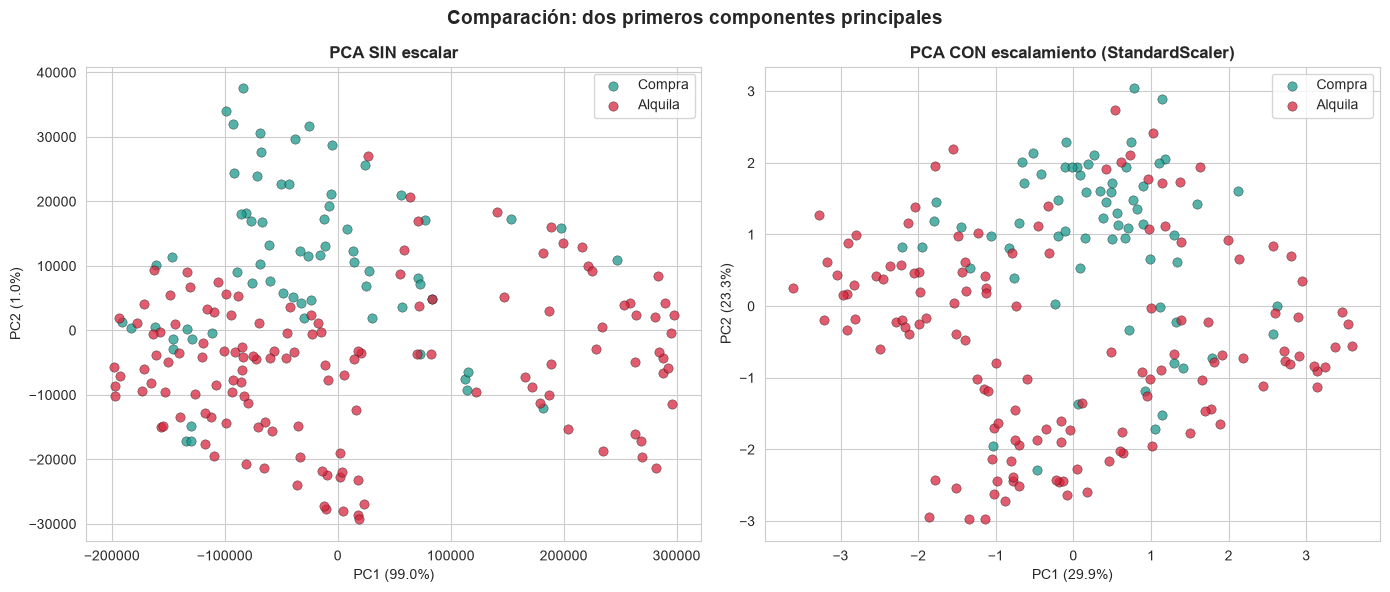

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, comp, titulo, pca_obj in zip(
        axes,
        [componentes_sin_escalar, componentes_escalado],
        ['PCA SIN escalar', 'PCA CON escalamiento (StandardScaler)'],
        [pca_sin_escalar, pca_escalado]):
    for val, color, etiqueta in [(1, '#1B998B', 'Compra'), (0, '#D7263D', 'Alquila')]:
        mask = (y == val).values
        ax.scatter(comp[mask, 0], comp[mask, 1], s=45, alpha=0.75, color=color, edgecolor='black', linewidth=0.3, label=etiqueta)
    ax.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(titulo, fontweight='bold')
    ax.legend()

plt.suptitle('Comparación: dos primeros componentes principales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_pca.png', dpi=120)
plt.show()


Interpretación
- **Sin escalar:** el primer componente está dominado casi por completo por la variable `vivienda` (valores en cientos de miles), que aplasta el efecto de variables como `hijos` o `estado_civil` (valores pequeños). La varianza explicada por PC1 es artificialmente altísima, pero no representa un buen resumen balanceado de todas las variables.
- **Con escalamiento:** todas las variables contribuyen de forma comparable (media 0, desviación 1), por lo que los componentes reflejan mejor la estructura real multivariada de los datos. Se observa más separación visual entre quienes compran y quienes alquilan, apoyada por varias variables a la vez (ingresos, ahorros, vivienda, gastos) y no solo por una.
- **Conclusión:** para este dataset, con variables en escalas tan distintas, **el escalamiento es obligatorio** antes de aplicar PCA; de lo contrario los resultados están sesgados por la variable de mayor magnitud.

#### Optimización: ¿cuántos componentes conservar?

Analizamos la varianza acumulada (con datos escalados) para decidir cuántos componentes usar.

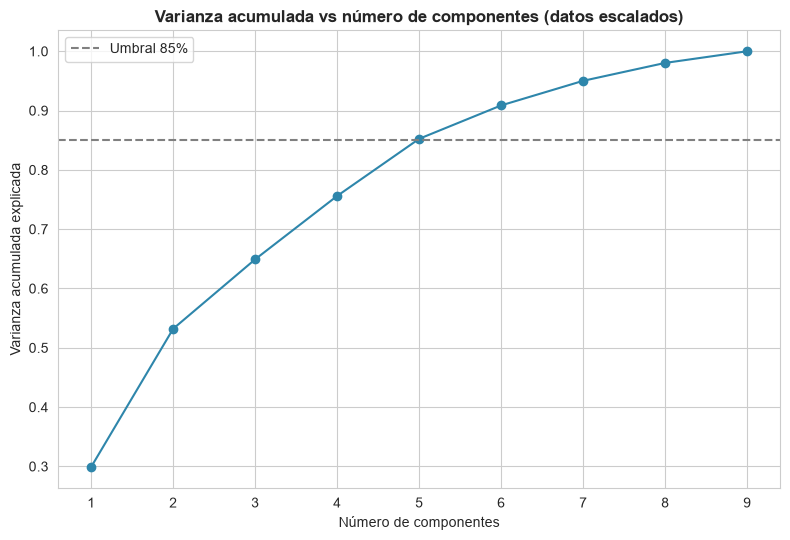

Componentes: 1 -> Varianza acumulada: 0.299
Componentes: 2 -> Varianza acumulada: 0.532
Componentes: 3 -> Varianza acumulada: 0.649
Componentes: 4 -> Varianza acumulada: 0.756
Componentes: 5 -> Varianza acumulada: 0.852
Componentes: 6 -> Varianza acumulada: 0.909
Componentes: 7 -> Varianza acumulada: 0.950
Componentes: 8 -> Varianza acumulada: 0.980
Componentes: 9 -> Varianza acumulada: 1.000


In [14]:
varianza_acumulada = np.cumsum(pca_escalado.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8,5.5))
ax.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o', color='#2E86AB')
ax.axhline(0.85, color='gray', linestyle='--', label='Umbral 85%')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada explicada')
ax.set_title('Varianza acumulada vs número de componentes (datos escalados)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('varianza_acumulada.png', dpi=120)
plt.show()

for i, v in enumerate(varianza_acumulada, start=1):
    print(f'Componentes: {i} -> Varianza acumulada: {v:.3f}')


#### Reducción de dimensionalidad final y justificación

Elegimos el número mínimo de componentes que explica al menos el **85%** de la varianza total, un umbral estándar que equilibra compresión de información con simplicidad del modelo.

In [15]:
n_componentes = np.argmax(varianza_acumulada >= 0.85) + 1
print(f'Número de componentes elegido: {n_componentes}')
print(f'Varianza acumulada con {n_componentes} componentes: {varianza_acumulada[n_componentes-1]:.3f}')

pca_final = PCA(n_components=n_componentes)
X_reducido = pca_final.fit_transform(X_escalado)

df_reducido = pd.DataFrame(X_reducido, columns=[f'PC{i+1}' for i in range(n_componentes)])
df_reducido['comprar'] = y.values
df_reducido.head()


Número de componentes elegido: 5
Varianza acumulada con 5 componentes: 0.852


,PC1,PC2,PC3,PC4,PC5,comprar
0,1.321915,-0.222950,1.599863,-0.885014,0.646617,1
1,1.147878,1.716967,0.395722,-0.447960,-0.687805,0
2,0.090369,1.836066,1.359382,0.337505,0.742387,1
3,3.455898,-0.078279,-0.202382,-1.573584,-0.068551,0
4,0.916933,-1.184676,0.190036,0.117804,-0.147753,1


**Justificación del número de componentes:** de las 9 variables originales, con el número de componentes calculado arriba (`n_componentes`) conservamos más del 85% de la información (varianza), reduciendo la dimensionalidad manteniendo casi toda la estructura de los datos. Esto es útil para simplificar modelos posteriores (regresión/clasificación) reduciendo riesgo de sobreajuste y tiempo de cómputo, sin sacrificar información relevante.

#### Guardado del modelo

In [16]:
joblib.dump({'scaler': scaler, 'pca': pca_final, 'n_componentes': n_componentes}, 'modelo_comprar_alquilar_pca.pkl')
print('Modelo guardado como modelo_comprar_alquilar_pca.pkl')


Modelo guardado como modelo_comprar_alquilar_pca.pkl
